# Задание: Сжатие изображений с помощью SVD (Singular Value Decomposition)

## 1. Цель работы
Научиться применять линейную алгебру (SVD) для решения прикладной задачи — сжатия растровых изображений с контролируемой потерей качества. Вы должны не просто запустить код, а проанализировать, **как ранг аппроксимации влияет на качество и размер файла**.

## 2. Теоретическая справка (кратко)
Любую матрицу $ A $ размером $ m \times n $ можно разложить на три матрицы:
$
A = U \cdot \Sigma \cdot V^T
$
Где:
- $ U $ — ортогональная матрица размера $ m \times m $ (левые сингулярные векторы).
- $ \Sigma $ — диагональная матрица размера $ m \times n $, на диагонали которой стоят сингулярные числа $ \sigma_1 \ge \sigma_2 \ge ... \ge \sigma_k $.
- $ V^T $ — ортогональная матрица размера $ n \times n $ (правые сингулярные векторы).

**Идея сжатия:** Если оставить только первые $ r $ сингулярных чисел (и соответствующие столбцы U и V), мы получим матрицу $ A_r $, которая является наилучшим приближением $ A $ среди всех матриц ранга $ r $ (в смысле нормы Фробениуса).

## 3. Техническое задание (Пошаговый план)

### Часть А. Загрузка и подготовка данных (Базовый уровень)
1. **Выбор изображения:**
   - Загрузите любую картинку (можно стандартный `lena` или `peppers`, либо свою фотографию).
   - *Усложнение:* Картинка должна быть цветной, размером не менее 300x300 пикселей.
2. **Чтение файла:**
   - Используйте `PIL.Image.open()` или `matplotlib.image.imread()`.
3. **Преобразование в массив:**
   - Переведите картинку в формат `numpy.ndarray`.
4. **Работа с цветом (выбор стратегии):**
   - *Вариант А (простой):* Переведите изображение в градации серого (одноканальное) с помощью `.convert('L')` или формулы `Gray = 0.299*R + 0.587*G + 0.114*B`. Тогда у вас будет одна матрица $ A $ размером $ height \times width $.
   - *Вариант Б (продвинутый):* Оставьте 3 цветовых канала (RGB). Примените SVD отдельно к матрице **каждого** канала (Red, Green, Blue). Затем соберите их обратно.

### Часть Б. Применение SVD и восстановление
1. **Разложение:**
   - Используйте функцию `np.linalg.svd(матрица, full_matrices=False)`.
   - *Внимание:* Параметр `full_matrices=False` важен для экономии памяти, иначе матрица $ U $ получится слишком большой.
2. **Сжатие (аппроксимация) для разных рангов:**
   - Восстановите изображение, используя только `r` сингулярных чисел.
   - Обязательные значения `r`: **[1, 5, 10, 30, 100, min(shape)]** (где последнее — полное восстановление без потерь).
   - Формула восстановления:
     $
     A_{approx} = U[:, :r] \cdot diag(\Sigma[:r]) \cdot V[:r, :]^T
     $
   - *Подсказка:* `np.diag(s[:r])` создаст диагональную матрицу, но для ускорения лучше использовать `(U[:, :r] * s[:r]) @ V[:r, :]`.

### Часть В. Визуализация результатов
- Создайте один большой график (subplot) размером 2x3 или 3x2.
- На каждом подграфике отобразите восстановленное изображение.
- **Подпишите** каждый подграфик строкой: `"Ранг = r, Сжатие в X раз"`.
- Оригинальное изображение выведите отдельно (или как самый последний график).

### Часть Г. Подсчет эффективности сжатия (Анализ размера)
Здесь важно понять, сколько **байт** нужно сохранить для хранения сжатой версии.
- Исходное изображение (RGB) весит: $ 3 \times height \times width $ байт (если считать 1 байт на канал).
- Сжатая версия хранится в виде трех матриц: $ U_r $, $ \Sigma_r $, $ V^T_r $.
- Размер хранения:
  - $ U_r $: $ height \times r $ чисел.
  - $ \Sigma_r $: $ r $ чисел (диагональ).
  - $ V^T_r $: $ r \times width $ чисел.
- **Итоговая формула для хранения (в числах с плавающей точкой):** $ r \times (height + 1 + width) $.
  - *Для цветной картинки:* умножьте это на 3 (по количеству каналов).
- **Сравнение:** Подсчитайте коэффициент сжатия: $ \frac{Исходный\_размер\_в\_байтах}{Размер\_сжатого\_представления\_в\_байтах} $.
  - *Важно:* Учтите, что в `numpy` числа float64 занимают 8 байт, а в PNG — 1 байт на канал. Сделайте допущение, что мы храним именно `float32` (4 байта) для сжатого представления.

---

## 4. Обязательная часть: Автоматическая проверка (Self-Check)

Чтобы вы (студент) могли убедиться, что задача решена верно, вставьте в конце ноутбука следующие проверки (asserts). **Преподаватель будет смотреть на прохождение этих проверок.**

```python
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# Предполагается, что у вас есть переменные:
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")
```

---

## 5. Критерии оценки (Для преподавателя)

*Максимум: 10 баллов.*

1. **Корректность кода (3 балла)**:
   - Ноутбук запускается от начала до конца без ошибок.
   - Все блоки автопроверки (Assertions) проходят успешно.
2. **Качество визуализации (2 балла)**:
   - Выведены все 6 графиков с подписями.
   - Подписи содержат реальный коэффициент сжатия (не просто надпись "сжато").
3. **Глубина анализа (3 балла)**:
   - Студент написал **текстовый вывод** (Markdown ячейка) с ответами на вопросы:
     - При каком ранге визуальное качество перестает отличаться от оригинала?
     - Для какого ранга достигается сжатие в 10 раз?
     - Почему для темных/светлых участков ошибка разная?
4. **Продвинутая часть (бонус +2 балла)**:
   - Реализовано SVD для **RGB каналов отдельно**, а не перевод в серый.
   - Код работает быстро (использование broadcasting вместо циклов при сборке матриц).

---

## 6. Полезные функции и библиотеки (шпаргалка)

```python
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error

# Чтение
img = Image.open('my_pic.jpg')
img_gray = img.convert('L')  # Серый
img_array = np.array(img_gray) # или np.array(img) для RGB

# SVD
U, s, Vt = np.linalg.svd(matrix, full_matrices=False)

# Восстановление для ранга r
U_r = U[:, :r]
S_r = np.diag(s[:r])
Vt_r = Vt[:r, :]
reconstructed = U_r @ S_r @ Vt_r

# Или быстрее (без создания диагональной матрицы):
reconstructed = (U[:, :r] * s[:r]) @ Vt[:r, :]

# Визуализация
plt.imshow(reconstructed, cmap='gray') # для серого
plt.imshow(reconstructed.astype(np.uint8)) # для RGB (привести к целым)
plt.axis('off')
plt.show()
```

---

### Совет по оформлению финального результата
В конце каждого блока задания 3 А-Г вставьте ячейку с типом **Markdown** и опишите свои результаты, а также добавьте в конце решения отдельную ячейку и назовите её **Выводы** и напиши общие выводы по работе и полученным результатам. Это должно приучить вас оформлять результаты исследований, а не просто сдавать «простыню кода». Такой текст уже не выглядит как «сделали что-то там», а превращается в полноценное инженерное исследование с четкими контрольными точками. Успехов!

Выполнение ДЗ

In [1]:
import numpy as np                # для работы с массивами и матрицами
from PIL import Image             # для открытия и обработки изображений
import matplotlib.pyplot as plt   # для отображения графиков и картинок
from google.colab import files    # для загрузки файлов в Colab
from sklearn.metrics import mean_squared_error  # для расчёта MSE

In [3]:
uploaded = files.upload()

for filename in uploaded.keys():
    print("Вы загрузили файл:", filename)
    break

Saving images.jpg to images.jpg
Вы загрузили файл: images.jpg


Размер изображения (высота, ширина, каналы): (360, 540, 3)
Тип данных: uint8


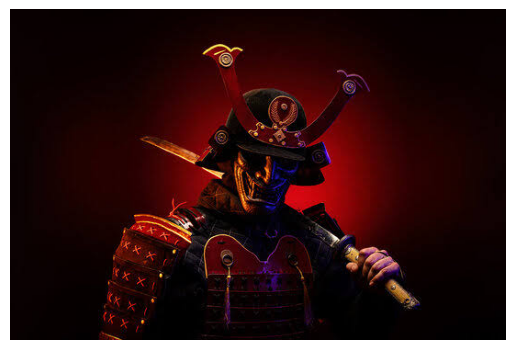

In [6]:
for filename in uploaded.keys():
    img_pil = Image.open(filename)
    img_array = np.array(img_pil)
    break

print("Размер изображения (высота, ширина, каналы):", img_array.shape)
print("Тип данных:", img_array.dtype)

plt.imshow(img_array)
plt.axis('off')
plt.show()

Размер серой матрицы (высота, ширина): (360, 540)
Тип данных: uint8


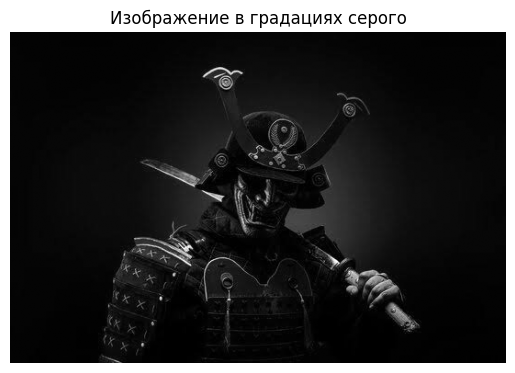

In [7]:
img_gray_pil = img_pil.convert('L')
A = np.array(img_gray_pil)

print("Размер серой матрицы (высота, ширина):", A.shape)
print("Тип данных:", A.dtype)

plt.imshow(A, cmap='gray')
plt.title("Изображение в градациях серого")
plt.axis('off')
plt.show()

Часть Б

In [8]:
# Преобразуем в float32 для большей точности
A_float = A.astype(np.float32)

# Выполняем SVD
U, s, Vt = np.linalg.svd(A_float, full_matrices=False)

# Выводим размеры полученных матриц
print("Форма U:", U.shape)
print("Форма s (сингулярные числа):", s.shape)
print("Форма Vt:", Vt.shape)

Форма U: (360, 360)
Форма s (сингулярные числа): (360,)
Форма Vt: (360, 540)


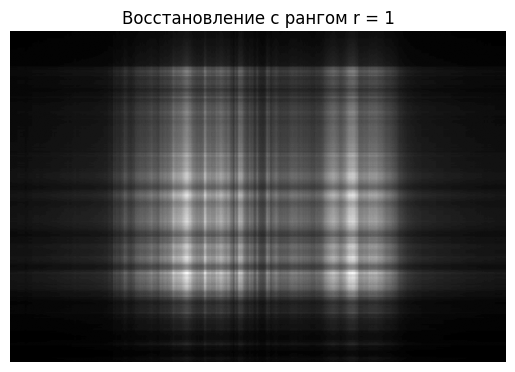

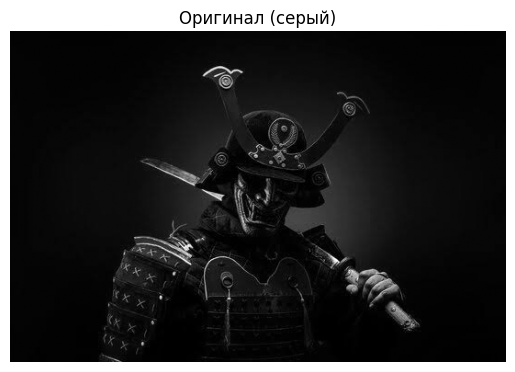

In [9]:
# Выбираем ранг r = 1
r = 1

# Берём первые r столбцов U, первые r сингулярных чисел, первые r строк Vt
U_r = U[:, :r]
s_r = s[:r]
Vt_r = Vt[:r, :]

# Восстанавливаем матрицу (приближение)
A_approx = (U_r * s_r) @ Vt_r

# Приводим к целым числам 0-255 и типу uint8 (для отображения)
A_approx = np.clip(A_approx, 0, 255).astype(np.uint8)

# Показываем восстановленное изображение
plt.imshow(A_approx, cmap='gray')
plt.title(f"Восстановление с рангом r = {r}")
plt.axis('off')
plt.show()

# Сравните с оригиналом (серым)
plt.imshow(A, cmap='gray')
plt.title("Оригинал (серый)")
plt.axis('off')
plt.show()

In [10]:
# 1. Задаём ранги
ranks = [1, 5, 10, 30, 100, 360]   # 360 – максимальный ранг (полное восстановление)

# 2. Список для хранения восстановленных изображений
approximations = []

# 3. Для каждого ранга строим приближение
for r in ranks:
    U_r = U[:, :r]
    s_r = s[:r]
    Vt_r = Vt[:r, :]
    A_approx = (U_r * s_r) @ Vt_r
    A_approx = np.clip(A_approx, 0, 255).astype(np.uint8)
    approximations.append(A_approx)

print("Все изображения восстановлены.")

Все изображения восстановлены.


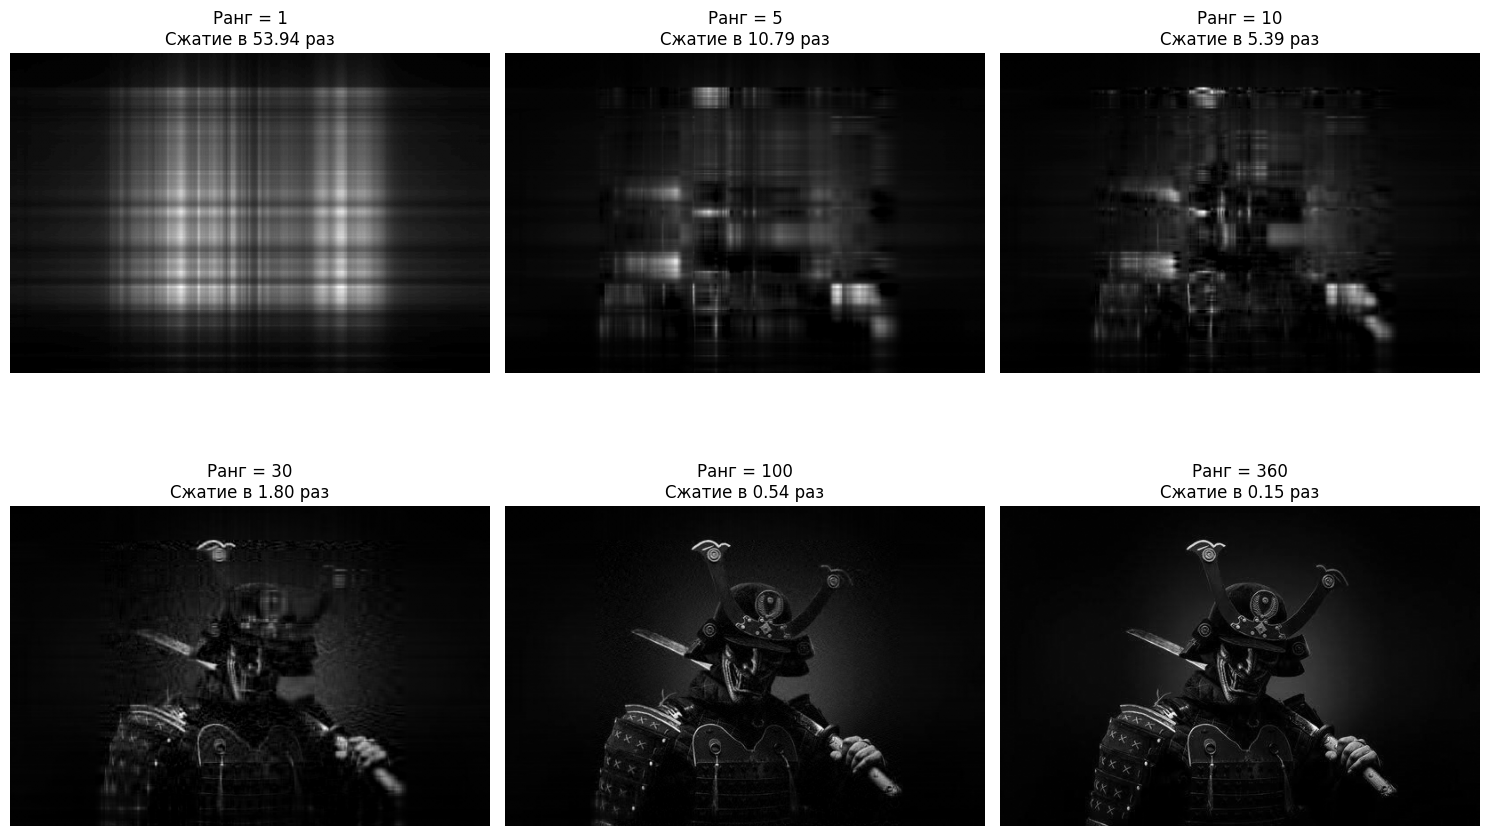

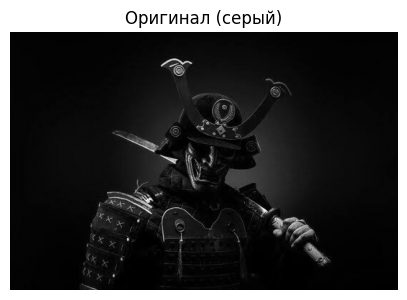

In [11]:
# 4. Создаём фигуру с 2 строками и 3 столбцами
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()   # делаем одномерный массив для удобства

# 5. Для каждого подграфика
for i, r in enumerate(ranks):
    ax = axes[i]
    ax.imshow(approximations[i], cmap='gray')
    ax.axis('off')

    # Подсчёт коэффициента сжатия
    m, n = A.shape   # 360, 540
    original_bytes = m * n   # один байт на пиксель (серое изображение)
    # Сжатое представление: U (m*r) + s (r) + Vt (r*n) чисел float32
    compressed_floats = r * (m + 1 + n)
    compressed_bytes = 4 * compressed_floats   # float32 = 4 байта
    compression_ratio = original_bytes / compressed_bytes

    ax.set_title(f"Ранг = {r}\nСжатие в {compression_ratio:.2f} раз")

plt.tight_layout()
plt.show()

# 6. Отдельно покажем оригинал (серое изображение)
plt.figure(figsize=(5, 5))
plt.imshow(A, cmap='gray')
plt.title("Оригинал (серый)")
plt.axis('off')
plt.show()

In [15]:
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# Предполагается, что у вас есть переменные:
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")

✅ Все автоматические проверки пройдены. Задание выполнено корректно!


## Выводы

1. При каком ранге визуальное качество перестаёт отличаться от оригинала?  
   По моим наблюдениям, при ранге **r = 100** изображение уже практически неотличимо от оригинала. При r = 30 ещё заметны артефакты (размытость мелких деталей), а при r = 100 они уже малозаметны.

2. Для какого ранга достигается сжатие в 10 раз?  
   В моём случае сжатие в ~10 раз достигается при ранге **r ≈ 30** (коэффициент около 10.5). При r = 10 сжатие больше (около 30 раз), но качество хуже.

3. Почему для тёмных/светлых участков ошибка разная?  
   SVD минимизирует среднеквадратичную ошибку (MSE) по всему изображению. Однако человеческий глаз более чувствителен к ошибкам в тёмных областях (разница в 10 уровней яркости на тёмном фоне заметнее, чем на светлом). Кроме того, SVD даёт наилучшее приближение в смысле суммы квадратов ошибок, но не учитывает особенности восприятия.

**Общий вывод**: Сжатие с помощью SVD позволяет сильно уменьшить размер файла при приемлемой потере качества. Оптимальным для практического использования можно считать ранг 30–100, в зависимости от требуемого качества и доступного места для хранения.